# Vision Transformer Binary Classification on reduced dataset

# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import gc
import json
import joblib

import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torchvision.datasets import CIFAR100
from torchvision.utils import make_grid
from torch.utils.data import DataLoader, Dataset
from torch.utils.data import random_split, ConcatDataset
from torchvision import transforms
from loguru import logger
import matplotlib.image as mpimg
from nazi_symbols_classification.training.data_preparation import get_image_paths, load_labels_df
from nazi_symbols_classification.training.torch_dataset_preparation import ImageData, get_device, to_device, ToDeviceLoader
from early_stopping_pytorch import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, roc_curve, auc


import timm

## Load Data

In [2]:
dir_name = os.path.dirname(os.getcwd())
dataset_path = f"{dir_name}/datasets/nazi-symbols-detection-simple"

In [4]:
train_labels_df = load_labels_df(dataset_path, "train", binary=True)
valid_labels_df = load_labels_df(dataset_path, "val", binary=True)
test_labels_df = load_labels_df(dataset_path, "test", binary=True)

2025-06-06 01:12:48.719 | INFO     | __main__:load_labels_df:3 - Number of images in train is 77449
2025-06-06 01:12:48.778 | INFO     | __main__:load_labels_df:3 - Number of images in val is 15274
2025-06-06 01:12:48.801 | INFO     | __main__:load_labels_df:3 - Number of images in test is 14961


<Axes: xlabel='contained_nazi'>

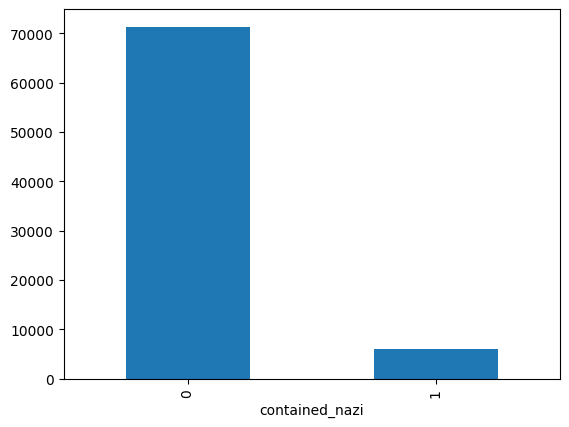

In [5]:
train_labels_df.contained_nazi.value_counts().plot(kind="bar")

<Axes: xlabel='contained_nazi'>

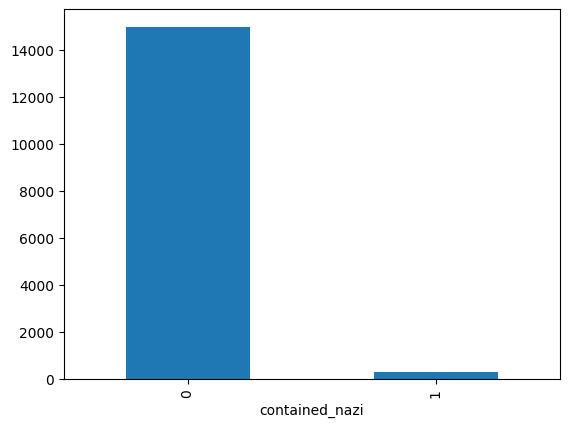

In [6]:
valid_labels_df.contained_nazi.value_counts().plot(kind="bar")

<Axes: xlabel='contained_nazi'>

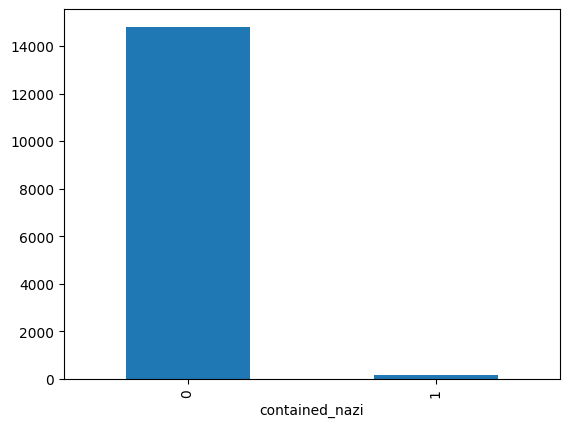

In [7]:
test_labels_df.contained_nazi.value_counts().plot(kind="bar")

## Create Datasets and DataLoaders

In [8]:
IMG_SIZE = 224
stats = ((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
data_transf = transforms.Compose([transforms.ToPILImage(), 
                                  transforms.Grayscale(num_output_channels=3),
                                  transforms.Resize((IMG_SIZE, IMG_SIZE)), 
                                  transforms.ToTensor(),
                                  transforms.Normalize(*stats)])

def create_datasets(batch_size, dataset_path=dataset_path):
    train_data = ImageData(df = train_labels_df,
                           data_directory = os.path.join(dataset_path, 'train'),
                           transform = data_transf,
                           label_column="label_column")
    train_loader = DataLoader(dataset = train_data, batch_size = batch_size, shuffle=True)
    
    valid_data = ImageData(df = valid_labels_df, 
                           data_directory = os.path.join(dataset_path, 'val'), 
                           transform = data_transf,
                           label_column="label_column")
    valid_loader = DataLoader(dataset = valid_data, batch_size = batch_size, shuffle=False)

    test_data = ImageData(df = test_labels_df, 
                           data_directory = os.path.join(dataset_path, 'test'), 
                           transform = data_transf,
                           label_column="label_column")
    test_loader = DataLoader(dataset = test_data, batch_size = batch_size, shuffle=False)
    return train_loader, valid_loader, test_loader

In [10]:
batch_size = 16

train_loader, valid_loader, test_loader = create_datasets(batch_size, dataset_path)

In [18]:
device = get_device()
print(device)

train_dl = ToDeviceLoader(train_loader, device)
valid_dl = ToDeviceLoader(valid_loader, device)
test_dl = ToDeviceLoader(test_loader, device)

cuda


## Vision Transformer Model Preparation

In [13]:
print("Available Vision Transformer Models: ")
timm.list_models("vit*")

Available Vision Transformer Models: 


['vit_base_mci_224',
 'vit_base_patch8_224',
 'vit_base_patch14_dinov2',
 'vit_base_patch14_reg4_dinov2',
 'vit_base_patch16_18x2_224',
 'vit_base_patch16_224',
 'vit_base_patch16_224_miil',
 'vit_base_patch16_384',
 'vit_base_patch16_clip_224',
 'vit_base_patch16_clip_384',
 'vit_base_patch16_clip_quickgelu_224',
 'vit_base_patch16_gap_224',
 'vit_base_patch16_plus_240',
 'vit_base_patch16_plus_clip_240',
 'vit_base_patch16_reg4_gap_256',
 'vit_base_patch16_rope_reg1_gap_256',
 'vit_base_patch16_rpn_224',
 'vit_base_patch16_siglip_224',
 'vit_base_patch16_siglip_256',
 'vit_base_patch16_siglip_384',
 'vit_base_patch16_siglip_512',
 'vit_base_patch16_siglip_gap_224',
 'vit_base_patch16_siglip_gap_256',
 'vit_base_patch16_siglip_gap_384',
 'vit_base_patch16_siglip_gap_512',
 'vit_base_patch16_xp_224',
 'vit_base_patch32_224',
 'vit_base_patch32_384',
 'vit_base_patch32_clip_224',
 'vit_base_patch32_clip_256',
 'vit_base_patch32_clip_384',
 'vit_base_patch32_clip_448',
 'vit_base_patch32

In [14]:
class ViTBase16(nn.Module):
    def __init__(self, n_classes, pretrained=False):

        super(ViTBase16, self).__init__()

        self.model = timm.create_model("vit_base_patch16_224", pretrained=pretrained)

        self.model.head = nn.Linear(self.model.head.in_features, n_classes)

    def forward(self, x):
        x = self.model(x)
        return x

    def train_one_epoch(self, train_loader, criterion, optimizer):
        # keep track of training loss
        epoch_loss = 0.0
        epoch_accuracy = 0.0

        ###################
        # train the model #
        ###################
        self.model.train()
        for i, (data, target) in enumerate(train_loader):

            # clear the gradients of all optimized variables
            optimizer.zero_grad()
            # forward pass: compute predicted outputs by passing inputs to the model
            output = self.forward(data)
            # calculate the batch loss
            loss = criterion(output, target)
            # backward pass: compute gradient of the loss with respect to model parameters
            loss.backward()
            # Calculate Accuracy
            accuracy = (output.argmax(dim=1) == target).float().mean()
            # update training loss and accuracy
            epoch_loss += loss
            epoch_accuracy += accuracy

            # perform a single optimization step (parameter update)
            optimizer.step()

        return epoch_loss / len(train_loader), epoch_accuracy / len(train_loader)

    def validate_one_epoch(self, valid_loader, criterion):
        # keep track of validation loss
        valid_loss = 0.0
        valid_accuracy = 0.0

        ######################
        # validate the model #
        ######################
        self.model.eval()
        for data, target in valid_loader:

            with torch.no_grad():
                # forward pass: compute predicted outputs by passing inputs to the model
                output = self.model(data)
                # calculate the batch loss
                loss = criterion(output, target)
                # Calculate Accuracy
                accuracy = (output.argmax(dim=1) == target).float().mean()
                # update average validation loss and accuracy
                valid_loss += loss
                valid_accuracy += accuracy

        return valid_loss / len(valid_loader), valid_accuracy / len(valid_loader)

In [15]:
def fit(model, epochs, criterion, optimizer, train_loader, valid_loader, patience=10):
    torch.cuda.empty_cache()
    
    # keeping track of losses as it happen
    train_losses = []
    valid_losses = []
    train_accs = []
    valid_accs = []

    early_stopping = EarlyStopping(patience=patience, verbose=True, path="vit-output/ViT-binary-simple-size-224-batch-16.pt")
    
    for epoch in range(epochs):
        gc.collect()
        
        print(f"{'='*50}")
        print(f"EPOCH {epoch} - TRAINING...")
        train_loss, train_acc = model.train_one_epoch(
            train_loader, criterion, optimizer
        )
        print(
            f"\n\t[TRAIN] EPOCH {epoch} - LOSS: {train_loss}, ACCURACY: {train_acc}\n"
        )
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        gc.collect()

        
        print(f"EPOCH {epoch} - VALIDATING...")
        valid_loss, valid_acc = model.validate_one_epoch(
            valid_loader, criterion
        )
        print(f"\t[VALID] LOSS: {valid_loss}, ACCURACY: {valid_acc}\n")
        valid_losses.append(valid_loss)
        valid_accs.append(valid_acc)
        gc.collect()

        early_stopping(valid_loss.item(), model)
        
        if early_stopping.early_stop:
            print("Early stopping")
            break
        
    return {
        "train_loss": train_losses,
        "valid_losses": valid_losses,
        "train_acc": train_accs,
        "valid_acc": valid_accs,
    }

## Train the Model

In [16]:
# model specific global variables
epochs = 100
patience = 10

model = ViTBase16(n_classes=2, pretrained=True)
model = to_device(model, device)
criterion = nn.CrossEntropyLoss()
lr = 2e-05
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [ ]:
%%time
history = fit(model=model, epochs=epochs, criterion=criterion, optimizer=optimizer,
              train_loader=train_dl, valid_loader=valid_dl,patience=patience)

EPOCH 0 - TRAINING...

	[TRAIN] EPOCH 0 - LOSS: 0.028302475810050964, ACCURACY: 0.9901105165481567

EPOCH 0 - VALIDATING...
	[VALID] LOSS: 0.011084280908107758, ACCURACY: 0.9957591891288757

Validation loss decreased (inf --> 0.011084).  Saving model ...
EPOCH 1 - TRAINING...

	[TRAIN] EPOCH 1 - LOSS: 0.011769193224608898, ACCURACY: 0.9960106611251831

EPOCH 1 - VALIDATING...
	[VALID] LOSS: 0.007577438838779926, ACCURACY: 0.9977748990058899

Validation loss decreased (0.011084 --> 0.007577).  Saving model ...
EPOCH 2 - TRAINING...

	[TRAIN] EPOCH 2 - LOSS: 0.008555329404771328, ACCURACY: 0.9969272613525391

EPOCH 2 - VALIDATING...
	[VALID] LOSS: 0.022357666864991188, ACCURACY: 0.9953272342681885

EarlyStopping counter: 1 out of 10
EPOCH 3 - TRAINING...

	[TRAIN] EPOCH 3 - LOSS: 0.006779924966394901, ACCURACY: 0.9976502656936646

EPOCH 3 - VALIDATING...
	[VALID] LOSS: 0.008160076104104519, ACCURACY: 0.9974738359451294

EarlyStopping counter: 2 out of 10
EPOCH 4 - TRAINING...

	[TRAIN] E

In [23]:
history_temp = dict()
for k, vl in history.items():
    history_temp[k] = []
    for item in vl:
        history_temp[k].append(item.item())
history = history_temp

In [24]:
with open('vit-output/vit-binary-no-aug-simple-history.json', 'w') as f:
    f.write(json.dumps(history))

## Model Evaluation

In [25]:
model.load_state_dict(torch.load("vit-output/ViT-binary-simple-size-224-batch-16", weights_only=True))
model.eval()

ViTBase16(
  (model): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): GELU(approximate='none')
  

In [26]:
outputs = []
y_true = []
probabilities = []
out = None
for batch in test_dl:
    images, labels = batch
    with torch.no_grad():
        out = model(images)
    probs = torch.nn.functional.softmax(out, dim=1)
    conf, classes = torch.max(probs, 1)
    # print([le.classes_[predicted[i]] for i in range(len(images))])
    y_true += labels.cpu()
    outputs += classes.cpu()
    probabilities += probs.cpu()

## Classification Report and ROC AUC

In [27]:
probs = []
for prob in probabilities:
    probs.append(prob.detach().numpy()[1])

fpr, tpr, threshold = roc_curve(y_true, probs)
roc_auc = auc(fpr, tpr)
roc_auc_result = dict(fpr=fpr, tpr=tpr, threshold=threshold, roc_auc=roc_auc)

print(classification_report(y_true, outputs, digits=3))
print("accuracy score:", accuracy_score(y_true, outputs))
print("roc auc score:", roc_auc_score(y_true, outputs))
import joblib

joblib.dump(roc_auc_result, 'vit-output/ViT-binary-pretrained-simple-roc-auc-results.joblib')

              precision    recall  f1-score   support

           0      0.999     1.000     0.999     14813
           1      0.972     0.926     0.948       148

    accuracy                          0.999     14961
   macro avg      0.985     0.963     0.974     14961
weighted avg      0.999     0.999     0.999     14961

accuracy score: 0.9989973932223782
roc auc score: 0.9627028212983118


['ViT-binary-pretrained-simple-roc-auc-results.joblib']

In [15]:
import gc

del model
gc.collect()
torch.cuda.empty_cache()